In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("..") / "data" / "processed" / "bike_share_daily.parquet"
df = pd.read_parquet(DATA_PATH)
df.shape

(3928341, 10)

In [2]:
df.columns.tolist()

['date',
 'city',
 'system',
 'station_name',
 'rider_type',
 'trips',
 'electric_trips',
 'lat',
 'lon',
 'capacity']

In [3]:
df[df["city"] == "San Francisco"].head()

,date,city,system,station_name,rider_type,trips,electric_trips,lat,lon,capacity
0,2023-01-01,San Francisco,Bay Wheels,10th Ave at Irving St,Casual,9,9,37.764233,-122.467376,23.0
1,2023-01-01,San Francisco,Bay Wheels,10th Ave at Irving St,Member,6,5,37.764220,-122.467379,23.0
2,2023-01-01,San Francisco,Bay Wheels,10th St at Mission St,Casual,1,0,37.355693,-121.892251,23.0
3,2023-01-01,San Francisco,Bay Wheels,11th St at Bryant St,Casual,14,8,37.770030,-122.411766,27.0
4,2023-01-01,San Francisco,Bay Wheels,11th St at Bryant St,Member,12,10,37.770024,-122.411789,27.0


In [4]:
df[df["city"] == "New York City"].head()

,date,city,system,station_name,rider_type,trips,electric_trips,lat,lon,capacity
271350,2024-06-30,New York City,Citi Bike,1 Ave & E 18 St,Member,2,1,40.733812,-73.980544,54.0
271351,2024-06-30,New York City,Citi Bike,1 Ave & E 30 St,Member,1,1,40.741444,-73.975361,38.0
271352,2024-06-30,New York City,Citi Bike,1 Ave & E 39 St,Casual,1,1,40.747140,-73.971130,39.0
271353,2024-06-30,New York City,Citi Bike,1 Ave & E 62 St,Member,2,0,40.761227,-73.960940,45.0
271354,2024-06-30,New York City,Citi Bike,1 Ave & E 68 St,Casual,1,1,40.765005,-73.958185,63.0


## San Francisco Growth Analysis — MTC February 2023 Investment

Looking at whether Bay Wheels ridership and station-network size grew after the Metropolitan Transportation Commission's February 2023 investment.

**Data caveat:** `bike_share_daily.parquet` has a gap for San Francisco — no rows for **January–May 2024** (the file was built from two separate download windows: 2023 full-year, then July 2024 onward). `2024-06` is also a partial/boundary month (19 rows, ~1 trip each) and should be excluded from any trend read. This doesn't affect the before/after comparison below since neither comparison window touches the gap, but it does mean the full monthly trend chart has a real hole in it, not a data quality artifact to ignore.

In [5]:
import matplotlib.pyplot as plt

sf = df[df["city"] == "San Francisco"].copy()
sf["month"] = sf["date"].dt.to_period("M")

# 2024-06 is a one-day boundary artifact (19 rows, ~1 trip each) from the
# two-part download window — exclude it from the trend so it doesn't read
# as a ridership collapse.
monthly_trips = (
    sf[sf["month"] != pd.Period("2024-06")]
    .groupby("month")["trips"]
    .sum()
)
monthly_trips

month
2023-01    134775
2023-02    138506
2023-03    152300
2023-04    185016
2023-05    186200
2023-06    190816
2023-07    197482
2023-08    218992
2023-09    213323
2023-10    229870
2023-11    196363
2023-12    156206
2024-07    297489
2024-08    314223
2024-09    320695
2024-10    361893
2024-11    250971
2024-12    209766
2025-01    272432
2025-02    238340
2025-03    313364
2025-04    334616
2025-05    365531
2025-06    361735
2025-07    372225
2025-08    410834
2025-09    441432
2025-10    464450
2025-11    354677
2025-12    260429
2026-01    333173
2026-02    329022
2026-03    466171
2026-04    425042
2026-05    457106
2026-06    476909
Freq: M, Name: trips, dtype: int64

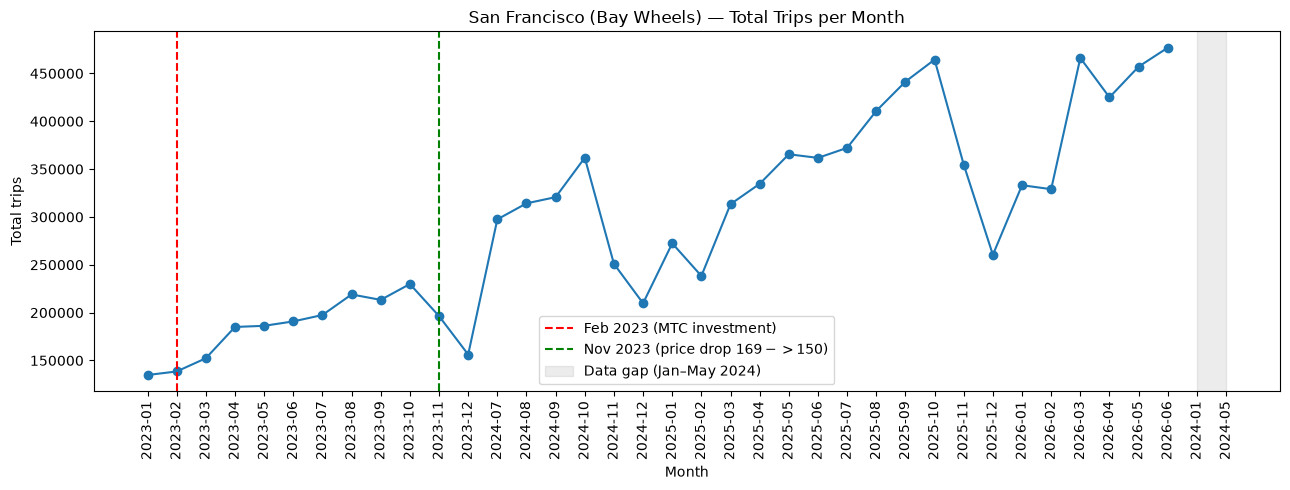

In [6]:
months_str = monthly_trips.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(months_str, monthly_trips.to_numpy(), marker="o")
ax.axvline(x="2023-02", color="red", linestyle="--", label="Feb 2023 (MTC investment)")
ax.axvline(x="2023-11", color="green", linestyle="--", label="Nov 2023 (price drop $169->$150)")
ax.axvspan("2024-01", "2024-05", color="grey", alpha=0.15, label="Data gap (Jan–May 2024)")
ax.set_title("San Francisco (Bay Wheels) — Total Trips per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total trips")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Average daily trips per station: right after Feb 2023 vs most recent

Comparing two equal-length (6-month) windows — the six months immediately after the Feb 2023 investment (Mar–Aug 2023) vs the six most recent available months (Jan–Jun 2026) — so the comparison isn't skewed by window size. Per-station, not just total trips, so network expansion (more stations) doesn't automatically inflate the "growth" story.

In [7]:
post_window = pd.period_range("2023-03", "2023-08", freq="M")
recent_window = pd.period_range("2026-01", "2026-06", freq="M")

comparison_rows = []
for label, window in [
    ("Post-Feb-2023 (Mar-Aug 2023)", post_window),
    ("Most recent (Jan-Jun 2026)", recent_window),
]:
    sub = sf[sf["month"].isin(window)]
    daily = sub.groupby("date").agg(trips=("trips", "sum"), stations=("station_name", "nunique"))
    daily["trips_per_station"] = daily["trips"] / daily["stations"]
    comparison_rows.append(
        {
            "window": label,
            "avg_daily_total_trips": daily["trips"].mean(),
            "avg_active_stations_per_day": daily["stations"].mean(),
            "avg_daily_trips_per_station": daily["trips_per_station"].mean(),
        }
    )

comparison = pd.DataFrame(comparison_rows).set_index("window").round(2)
comparison

,avg_daily_total_trips,avg_active_stations_per_day,avg_daily_trips_per_station
window,,,
Post-Feb-2023 (Mar-Aug 2023),6145.68,430.98,14.18
Most recent (Jan-Jun 2026),13742.67,560.44,24.32


### Station network size: Feb 2023 vs now

In [8]:
feb2023_stations = set(sf.loc[sf["month"] == pd.Period("2023-02"), "station_name"].unique())
latest_month = sf["month"].max()
latest_stations = set(sf.loc[sf["month"] == latest_month, "station_name"].unique())

net_new = latest_stations - feb2023_stations
lost = feb2023_stations - latest_stations
pct_growth = 100 * (len(latest_stations) - len(feb2023_stations)) / len(feb2023_stations)

station_summary = pd.DataFrame(
    {
        "metric": [
            "Stations active in Feb 2023",
            f"Stations active in {latest_month}",
            "Net new stations",
            "Stations no longer active",
            "Net network growth (%)",
        ],
        "value": [
            len(feb2023_stations),
            len(latest_stations),
            len(net_new),
            len(lost),
            round(pct_growth, 1),
        ],
    }
).set_index("metric")
station_summary

,value
metric,
Stations active in Feb 2023,509.0
Stations active in 2026-06,638.0
Net new stations,214.0
Stations no longer active,85.0
Net network growth (%),25.3


### Price history: the Nov 2023 fare change

Bay Wheels changed pricing on **2023-11-02**: annual membership $169 → $150, e-bike per-minute rate $0.20 → $0.15. This is published pricing, not something derivable from the trip data, so it's encoded as an explicit lookup table (`PRICE_HISTORY`) and mapped onto each SF row by date.

In [9]:
# Known Bay Wheels price changes for San Francisco (published pricing).
# Each bracket covers dates in [effective_from, effective_until).
PRICE_HISTORY = [
    {
        "effective_from": pd.Timestamp.min,
        "effective_until": pd.Timestamp("2023-11-02"),
        "membership_price": 169,
        "ebike_per_min_price": 0.20,
    },
    {
        "effective_from": pd.Timestamp("2023-11-02"),
        "effective_until": pd.Timestamp.max,
        "membership_price": 150,
        "ebike_per_min_price": 0.15,
    },
]


def assign_price_columns(frame, history):
    frame = frame.copy()
    frame["membership_price"] = pd.NA
    frame["ebike_per_min_price"] = pd.NA
    for bracket in history:
        mask = (frame["date"] >= bracket["effective_from"]) & (frame["date"] < bracket["effective_until"])
        frame.loc[mask, "membership_price"] = bracket["membership_price"]
        frame.loc[mask, "ebike_per_min_price"] = bracket["ebike_per_min_price"]
    return frame


sf = assign_price_columns(sf, PRICE_HISTORY)

# Verify the mapping: each price bracket should line up with the correct date range.
sf.groupby(["membership_price", "ebike_per_min_price"])["date"].agg(["min", "max", "count"])

,,min,max,count
membership_price,ebike_per_min_price,,,
150,0.15,2023-11-02,2026-06-30,719756
169,0.20,2023-01-01,2023-11-01,226734


### Ridership before vs after the Nov 2023 price drop

Comparing two symmetric 2-month windows immediately adjacent to the change: Sep–Oct 2023 (old pricing) vs Nov–Dec 2023 (new pricing). Kept short and symmetric on purpose — the Jan–May 2024 gap means the "after" window can't be extended further without crossing into discontinuous data, and mismatched window lengths would bias the comparison.

**This window also spans a known seasonal transition** (ridership drops from early autumn into late autumn/winter every year in this dataset — see the monthly chart above). So alongside the 2023 before/after, the same Sep-Oct → Nov-Dec comparison is run for **2025**, a year with no price change at all in that window — as a control for how much of any 2023 change is just seasonality rather than price.

In [10]:
def seasonal_window_comparison(pre_period, post_period, pre_label, post_label):
    rows = []
    for label, window in [(pre_label, pre_period), (post_label, post_period)]:
        sub = sf[sf["month"].isin(window)]
        daily = sub.groupby("date").agg(trips=("trips", "sum"), stations=("station_name", "nunique"))
        daily["trips_per_station"] = daily["trips"] / daily["stations"]
        rows.append(
            {
                "window": label,
                "avg_daily_total_trips": daily["trips"].mean(),
                "avg_active_stations_per_day": daily["stations"].mean(),
                "avg_daily_trips_per_station": daily["trips_per_station"].mean(),
            }
        )
    return pd.DataFrame(rows).set_index("window").round(2)


price_change_comparison = seasonal_window_comparison(
    pd.period_range("2023-09", "2023-10", freq="M"),
    pd.period_range("2023-11", "2023-12", freq="M"),
    "2023: Before price drop (Sep-Oct, $169/$0.20)",
    "2023: After price drop (Nov-Dec, $150/$0.15)",
)
price_change_comparison

,avg_daily_total_trips,avg_active_stations_per_day,avg_daily_trips_per_station
window,,,
"2023: Before price drop (Sep-Oct, $169/$0.20)",7265.46,452.93,16.01
"2023: After price drop (Nov-Dec, $150/$0.15)",5779.82,438.84,12.97


In [11]:
# Seasonality control: same Sep-Oct -> Nov-Dec transition in 2025, when
# price was flat at $150/$0.15 all year — no price change in this window.
seasonal_control_comparison = seasonal_window_comparison(
    pd.period_range("2025-09", "2025-10", freq="M"),
    pd.period_range("2025-11", "2025-12", freq="M"),
    "2025 control: Sep-Oct (no price change)",
    "2025 control: Nov-Dec (no price change)",
)
seasonal_control_comparison

,avg_daily_total_trips,avg_active_stations_per_day,avg_daily_trips_per_station
window,,,
2025 control: Sep-Oct (no price change),14850.52,543.70,27.28
2025 control: Nov-Dec (no price change),10083.70,520.64,19.06


**Reading the two tables together:** avg daily trips per station fell from Sep-Oct to Nov-Dec in *both* 2023 (16.0 → 13.0, about -19%) and 2025 (27.3 → 19.1, about -30%), even though 2025 had no price change at all in that window. The seasonal drop-off is real and larger in the control year than in 2023. That means the raw 2023 before/after **cannot be read as "the price drop hurt ridership"** — seasonality alone would predict a bigger drop than what was actually observed. If anything, 2023's decline being smaller than the seasonal baseline is weakly consistent with the price drop partially offsetting the usual seasonal fall-off, but this is one year of control data against one year of the actual event — not enough to call it a causal effect either way.

## Findings

**The Feb 2023 investment shows up as sustained growth. The Nov 2023 price drop does not show a clear, isolatable effect — the raw before/after is confounded by seasonality.**

- **Ridership per station grew:** average daily trips per station went from **~14.2** (Mar–Aug 2023, right after the Feb 2023 investment) to **~24.3** (Jan–Jun 2026, most recent) — a **+71% increase**. This is per-station, so it isn't just "more stations means more trips."
- **Total daily ridership more than doubled:** average daily total trips rose from **~6,150** to **~13,740** — a **+124% increase**, reflecting both more trips per station and a larger network.
- **The network expanded:** San Francisco had **509 active stations** in Feb 2023 vs **638** in the most recent month (Jun 2026) — **214 net-new stations, 85 stations no longer active**, for **+25% net growth** in station count.
- **The monthly trend chart shows sustained growth, not a spike:** trips climb steadily from early 2023 through mid-2023, and the post-gap period (Jul 2024 onward) continues that same upward trajectory into 2026, rather than flattening or reverting.
- **The Nov 2023 price drop ($169→$150 membership, $0.20→$0.15/min e-bike) does not show a clean ridership response.** Avg daily trips per station fell from Sep-Oct to Nov-Dec 2023 (16.0 → 13.0, -19%), but the same seasonal transition in 2025 — a year with no price change — fell *more* (27.3 → 19.1, -30%). Seasonality dominates this window; the data doesn't support a "the price drop grew ridership" claim, though it's weakly consistent with the drop softening the usual seasonal decline. Would need multiple non-event years of the same window to say more than that.

**Caveat:** there's a real gap in this dataset for Jan–May 2024 (see the note above), so we can't see exactly how the trend evolved through that stretch. The Feb 2023 comparison avoids the gap entirely (Mar–Aug 2023 vs Jan–Jun 2026), so those headline growth numbers aren't affected — but a reviewer will reasonably ask about that missing stretch, so it's worth closing before this goes in a report. The gap is also *why* the Nov 2023 "after" window is stuck at just 2 months (Nov-Dec 2023) instead of extending further, which limits how much weight that comparison can carry.